# Regularization sweep (L1 vs L2) for the PL inverse Ising fit

This investigates the **regularization** of the per-spin pseudo-likelihood fit (`k2dex.models.fit_pl_ising`) — both the *penalty type* (L1/Lasso vs L2/Ridge) and the *strength* `C`. ("Normalization" in the original question is really regularization: the penalty on the logistic-regression coefficients that become `J`.)

`SPECIES_LR_C = 0.1` is the current production setting. It was never swept — it came from moving `1.0 -> 0.1` once, which fixed the immediate problem. This notebook actually sweeps it.

**Two complementary criteria**, both plotted vs `C` with L1 and L2 on the same axes:

1. **Held-out pseudo-log-likelihood** — the exact objective the PL fit maximizes, evaluated out of sample. The principled model-selection criterion for the penalty/strength.
2. **Leave-one-out completion MRR / hit-rate** — the downstream task the webapp cares about. Uses the same mean-field scorer as `validation.ipynb`.

Plus J-structure diagnostics (sparsity, mean `|J|`) so you can see what L1 is actually doing.

**Methodology** mirrors `validation.ipynb`: team-level random 90/10 split (`VALIDATION_SEED`), species vocab built on the full corpus for index consistency, fit on train teams only.

**Solvers**: L2 uses `lbfgs` (byte-identical to `k2dex.models.fit_pl_ising`, so the L2 curve *is* the production model across `C`). L1 can't use lbfgs, so it uses `liblinear` — the classic Lasso-logistic coordinate-descent solver. Caveat: liblinear regularizes the intercept (`h`), lbfgs does not, so the two penalties treat `h` slightly differently. For an intercept-clean rerun (or to add elastic-net) swap in `solver="saga"`.

Runtime is a few minutes; this is a research notebook, run once.

In [2]:
from __future__ import annotations
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

from k2dex import tournament_ingest
from k2dex.constants import (
    SPECIES_LR_LAMBDA, SPECIES_ITEM_LR_LAMBDA, PHASE2_MIN_TEAM_COUNT,
    VALIDATION_SEED, VALIDATION_TEAM_FRAC_TEST,
)

tournaments = tournament_ingest.load_cached_tournaments()
print(f"tournaments:            {len(tournaments)}")
print(f"total team-appearances: {sum(len(t.teams) for t in tournaments)}")

tournaments:            198
total team-appearances: 23608


## Train/test split

Team-level random 90/10 — pool all teams, shuffle once under `VALIDATION_SEED`, slice off `VALIDATION_TEAM_FRAC_TEST`. Same split as `validation.ipynb` so results are comparable.

In [3]:
all_teams_full = tournament_ingest.all_teams(tournaments)
n_total = len(all_teams_full)

split_rng = np.random.default_rng(VALIDATION_SEED)
perm = split_rng.permutation(n_total)
n_test = int(round(n_total * VALIDATION_TEAM_FRAC_TEST))
test_idx, train_idx = perm[:n_test], perm[n_test:]

train_teams_full = [all_teams_full[i] for i in train_idx]
test_teams_full = [all_teams_full[i] for i in test_idx]
train_teams = tournament_ingest.species_only_teams(train_teams_full)
test_teams = tournament_ingest.species_only_teams(test_teams_full)

print(f"train: {len(train_teams):>6} teams")
print(f"test:  {len(test_teams):>6} teams")

train:  21247 teams
test:    2361 teams


## Species vocab + indicator matrices

Vocab from the full corpus (cutoff `PHASE2_MIN_TEAM_COUNT`); `J, h` are refit per `(penalty, C)` on `X_train` only. We sweep species (Phase 2) here as the fast starting point — the same harness works on the pair (Phase 3) matrix; see the closing notes.

In [4]:
species_counts = Counter(name for team in (train_teams + test_teams) for name in team)
vocab = sorted(name for name, c in species_counts.items() if c >= PHASE2_MIN_TEAM_COUNT)
name_to_idx = {name: i for i, name in enumerate(vocab)}
V = len(vocab)


def teams_to_matrix(teams, name_to_idx, V):
    X = np.zeros((len(teams), V), dtype=np.int8)
    for ti, team in enumerate(teams):
        for name in team:
            j = name_to_idx.get(name)
            if j is not None:
                X[ti, j] = 1
    return X


X_train = teams_to_matrix(train_teams, name_to_idx, V).astype(np.int32)
X_test = teams_to_matrix(test_teams, name_to_idx, V).astype(np.int32)
m_train = X_train.mean(axis=0)
print(f"species vocab: {V}   X_train: {X_train.shape}   X_test: {X_test.shape}")

species vocab: 194   X_train: (21247, 194)   X_test: (2361, 194)


## Parametrized PL fit

Identical to `k2dex.models.fit_pl_ising` except the penalty (and therefore solver) is selectable. For `penalty='l2'` this reproduces the production fit exactly; for `'l1'` it routes through `liblinear`. Symmetrize the same way: `J = (J_asym + J_asym.T) / 2`, zero diagonal.

Note for L1: the two directional estimates of an edge (`i`-on-rest vs `j`-on-rest) can disagree on whether it's zero. Averaging then yields a small nonzero, which *erodes* the sparsity L1 buys. The sparsity diagnostic below is measured on the symmetrized `J`, so it reflects that erosion honestly. (Structure-learning practice uses an explicit AND/OR edge rule instead of averaging — out of scope for this first pass.)

In [5]:
def fit_pl_ising_pen(X, *, penalty, C, max_iter=1000):
    """fit_pl_ising with a selectable penalty.

    penalty='l2' -> lbfgs, identical to k2dex.models.fit_pl_ising.
    penalty='l1' -> liblinear (coordinate descent), the standard Lasso-logistic
    solver. liblinear regularizes the intercept; lbfgs does not.
    """
    X = X.astype(np.int32, copy=False)
    n, V = X.shape
    solver = "lbfgs" if penalty == "l2" else "liblinear"
    J_asym = np.zeros((V, V), dtype=np.float64)
    h = np.zeros(V, dtype=np.float64)
    for i in range(V):
        y = X[:, i]
        if y.sum() < 2 or (1 - y).sum() < 2:
            continue
        mask = np.ones(V, dtype=bool)
        mask[i] = False
        lr = LogisticRegression(penalty=penalty, C=C, solver=solver, max_iter=max_iter)
        lr.fit(X[:, mask], y)
        h[i] = lr.intercept_[0]
        J_asym[i, mask] = lr.coef_[0]
    J = 0.5 * (J_asym + J_asym.T)
    np.fill_diagonal(J, 0.0)
    return J, h

## Evaluation criteria

**Held-out PLL** — mean per-team pseudo-log-likelihood: `sum_i log P(x_i | x_{-i})` under the fitted `(J, h)`, averaged over teams. The conditional logit for spin `i` is `h_i + sum_{j!=i} J_ij x_j` (diagonal is zero), so the whole thing is one matmul `X @ J + h`. Computed on both train and test to expose the overfit gap.

**Completion** — leave-one-out: hold out one species, score every candidate via clamped mean-field, rank the true held-out species. Same MF scorer as `validation.ipynb`. Problems are precomputed once so every `(penalty, C)` sees identical held-out slots.

In [6]:
def held_out_pll(X_eval, J, h):
    """Mean per-team held-out pseudo-log-likelihood under (J, h)."""
    logits = X_eval @ J + h
    nll_pos = np.logaddexp(0.0, -logits)   # -log sigmoid(logits)
    nll_neg = np.logaddexp(0.0, logits)    # -log(1 - sigmoid(logits))
    ll = -(X_eval * nll_pos + (1 - X_eval) * nll_neg)
    return float(ll.sum() / X_eval.shape[0])


def score_ising_meanfield(held_in_idx, *, J, h, n_iters=200, tol=1e-4, damp=0.5):
    """Damped mean-field marginals, held-in clamped to 1. Mirrors validation.ipynb."""
    V_local = len(h)
    fixed = np.zeros(V_local, dtype=bool)
    fixed[list(held_in_idx)] = True
    m = 1.0 / (1.0 + np.exp(-h))
    m[fixed] = 1.0
    for _ in range(n_iters):
        m_new = 1.0 / (1.0 + np.exp(-(h + J @ m)))
        m_new[fixed] = 1.0
        delta = float(np.max(np.abs(m_new[~fixed] - m[~fixed])))
        m = damp * m_new + (1.0 - damp) * m
        m[fixed] = 1.0
        if delta < tol:
            break
    return m


# Fixed leave-one-out problems: every (penalty, C) scored on identical held-out slots.
COMPLETION_SEED = 42
_eval_rng = np.random.default_rng(COMPLETION_SEED)
completion_problems = []
for team in test_teams:
    species = sorted(team)
    if len(species) != 6 or not all(s in name_to_idx for s in species):
        continue
    idxs = np.array([name_to_idx[s] for s in species])
    ho = int(_eval_rng.integers(6))
    completion_problems.append((np.delete(idxs, ho), int(idxs[ho])))
print(f"completion problems (in-vocab test teams): {len(completion_problems)}")


def completion_metric(problems, J, h):
    """Leave-one-out completion under MF. Returns (MRR, top-1, top-5)."""
    rr = np.empty(len(problems))
    hit1 = hit5 = 0
    for n, (held_in, held_out) in enumerate(problems):
        scores = score_ising_meanfield(held_in, J=J, h=h).copy()
        scores[held_in] = -np.inf
        rank = 1 + int((scores > scores[held_out]).sum())
        rr[n] = 1.0 / rank
        hit1 += rank <= 1
        hit5 += rank <= 5
    N = len(problems)
    return float(rr.mean()), hit1 / N, hit5 / N

completion problems (in-vocab test teams): 2358


## The sweep

For each penalty and each `C` on a log grid: refit `(J, h)`, then record held-out PLL (train + test), completion MRR / hit-rates, and J-structure diagnostics.

In [7]:
C_GRID = np.logspace(-3, 1, 13)   # 0.001 .. 10
PENALTIES = ["l2", "l1"]
EPS = 1e-6
iu = np.triu_indices(V, 1)

sweep = {p: {"C": [], "train_pll": [], "test_pll": [],
             "mrr": [], "hit1": [], "hit5": [],
             "sparsity": [], "mean_abs_j": []}
         for p in PENALTIES}

for penalty in PENALTIES:
    for C in C_GRID:
        J, h = fit_pl_ising_pen(X_train, penalty=penalty, C=C)
        mrr, hit1, hit5 = completion_metric(completion_problems, J, h)
        offdiag = np.abs(J[iu])
        s = sweep[penalty]
        s["C"].append(C)
        s["train_pll"].append(held_out_pll(X_train, J, h))
        s["test_pll"].append(held_out_pll(X_test, J, h))
        s["mrr"].append(mrr)
        s["hit1"].append(hit1)
        s["hit5"].append(hit5)
        s["sparsity"].append(float((offdiag < EPS).mean()))
        s["mean_abs_j"].append(float(offdiag.mean()))
        print(f"{penalty}  C={C:8.3f}  test_pll={s['test_pll'][-1]:8.3f}  "
              f"MRR={mrr:.3f}  top1={hit1:.1%}  top5={hit5:.1%}  "
              f"sparsity={s['sparsity'][-1]:5.1%}")
    print()

l2  C=   0.001  test_pll= -15.836  MRR=0.390  top1=24.8%  top5=54.0%  sparsity= 0.8%
l2  C=   0.002  test_pll= -14.896  MRR=0.433  top1=29.3%  top5=58.4%  sparsity= 0.4%
l2  C=   0.005  test_pll= -13.905  MRR=0.465  top1=32.6%  top5=62.3%  sparsity= 0.1%
l2  C=   0.010  test_pll= -12.935  MRR=0.484  top1=34.3%  top5=65.3%  sparsity= 0.0%
l2  C=   0.022  test_pll= -12.103  MRR=0.495  top1=35.1%  top5=66.8%  sparsity= 0.0%
l2  C=   0.046  test_pll= -11.623  MRR=0.481  top1=33.5%  top5=65.9%  sparsity= 0.0%
l2  C=   0.100  test_pll= -11.836  MRR=0.457  top1=30.9%  top5=63.0%  sparsity= 0.0%
l2  C=   0.215  test_pll= -12.765  MRR=0.427  top1=27.4%  top5=59.3%  sparsity= 0.0%
l2  C=   0.464  test_pll= -13.970  MRR=0.409  top1=25.4%  top5=57.6%  sparsity= 0.0%
l2  C=   1.000  test_pll= -14.731  MRR=0.399  top1=24.5%  top5=56.2%  sparsity= 0.0%
l2  C=   2.154  test_pll= -14.757  MRR=0.396  top1=24.0%  top5=56.0%  sparsity= 0.0%
l2  C=   4.642  test_pll= -14.321  MRR=0.395  top1=24.0%  top5=56

/var/folders/mg/tm4y2kts70l6yk40zqzz1w_r0000gn/T/ipykernel_21513/375546737.py:18: RuntimeWarning: overflow encountered in exp
  m_new = 1.0 / (1.0 + np.exp(-(h + J @ m)))


l1  C=   4.642  test_pll= -14.540  MRR=0.365  top1=21.2%  top5=53.3%  sparsity=17.4%


/var/folders/mg/tm4y2kts70l6yk40zqzz1w_r0000gn/T/ipykernel_21513/375546737.py:18: RuntimeWarning: overflow encountered in exp
  m_new = 1.0 / (1.0 + np.exp(-(h + J @ m)))


l1  C=  10.000  test_pll= -11.609  MRR=0.364  top1=21.4%  top5=53.6%  sparsity=11.6%



## Best-`C` summary

Argmax of each criterion per penalty, with the current production `SPECIES_LR_C` for reference. Note where held-out PLL and completion MRR disagree — PLL favors the calibrated conditional distribution, MRR favors ranking; they need not pick the same `C`.

In [8]:
for penalty in PENALTIES:
    s = sweep[penalty]
    i_pll = int(np.argmax(s["test_pll"]))
    i_mrr = int(np.argmax(s["mrr"]))
    print(f"{penalty}:  best test-PLL @ Lambda={1/s['C'][i_pll]:7.3f} (pll={s['test_pll'][i_pll]:.3f})"
          f"   |   best MRR @ Lambda={1/s['C'][i_mrr]:7.3f} (mrr={s['mrr'][i_mrr]:.3f})")
print(f"\ncurrent production SPECIES_LR_LAMBDA = {SPECIES_LR_LAMBDA}  (L2)")

l2:  best test-PLL @ Lambda= 21.544 (pll=-11.623)   |   best MRR @ Lambda= 46.416 (mrr=0.495)
l1:  best test-PLL @ Lambda=  0.100 (pll=-11.609)   |   best MRR @ Lambda= 46.416 (mrr=0.488)

current production SPECIES_LR_LAMBDA = 10.0  (L2)


## Plots

L1 and L2 on shared axes vs `C` (log scale). Gray dotted vertical line marks the current production `SPECIES_LR_C`.

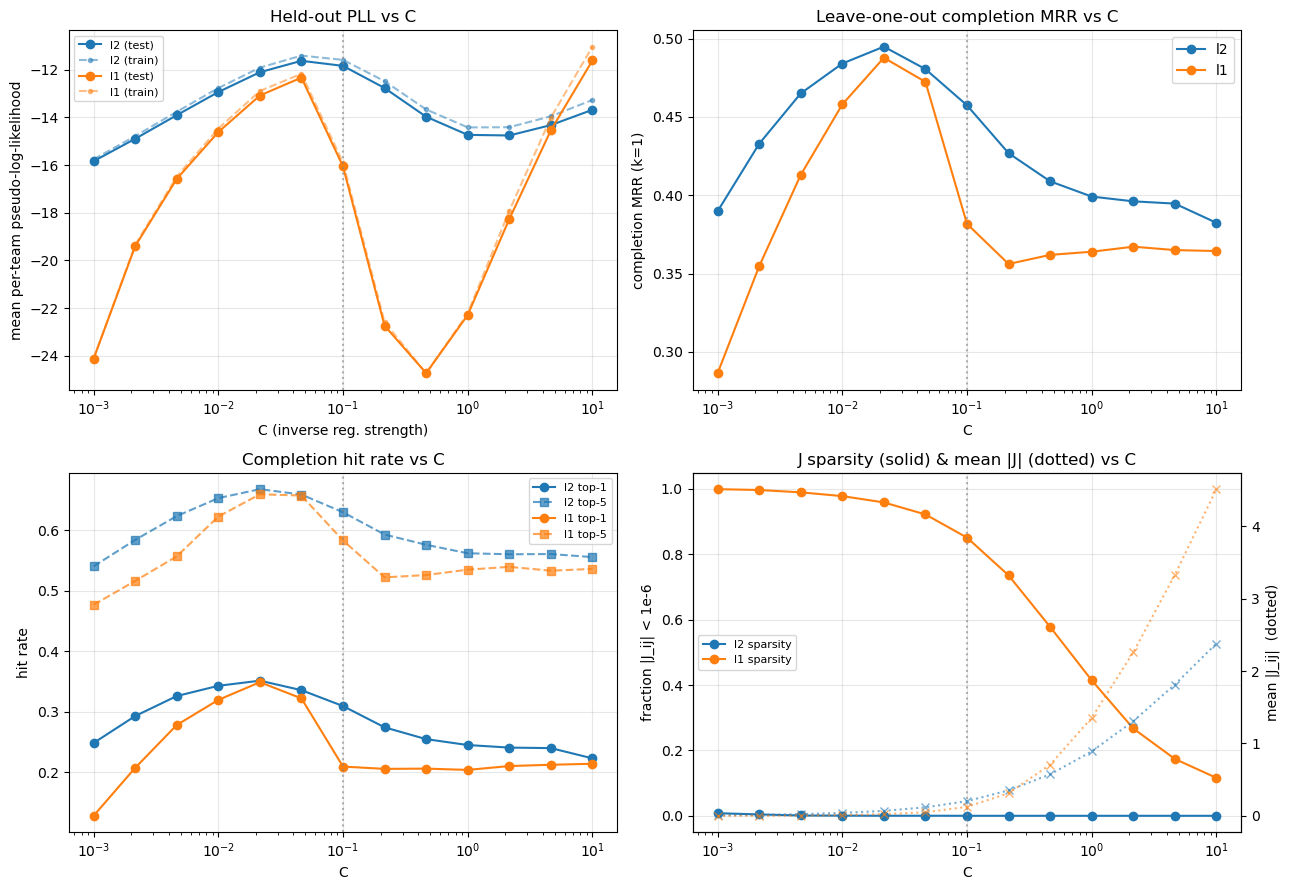

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
colors = {"l2": "C0", "l1": "C1"}

ax = axes[0, 0]
for p in PENALTIES:
    ax.plot(sweep[p]["C"], sweep[p]["test_pll"], marker="o", color=colors[p], label=f"{p} (test)")
    ax.plot(sweep[p]["C"], sweep[p]["train_pll"], marker=".", ls="--", color=colors[p],
            alpha=0.5, label=f"{p} (train)")
ax.set_xscale("log"); ax.set_xlabel("C (inverse reg. strength)")
ax.set_ylabel("mean per-team pseudo-log-likelihood")
ax.set_title("Held-out PLL vs C"); ax.grid(alpha=0.3); ax.legend(fontsize=8)

ax = axes[0, 1]
for p in PENALTIES:
    ax.plot(sweep[p]["C"], sweep[p]["mrr"], marker="o", color=colors[p], label=p)
ax.set_xscale("log"); ax.set_xlabel("C"); ax.set_ylabel("completion MRR (k=1)")
ax.set_title("Leave-one-out completion MRR vs C"); ax.grid(alpha=0.3); ax.legend()

ax = axes[1, 0]
for p in PENALTIES:
    ax.plot(sweep[p]["C"], sweep[p]["hit1"], marker="o", color=colors[p], label=f"{p} top-1")
    ax.plot(sweep[p]["C"], sweep[p]["hit5"], marker="s", ls="--", color=colors[p],
            alpha=0.7, label=f"{p} top-5")
ax.set_xscale("log"); ax.set_xlabel("C"); ax.set_ylabel("hit rate")
ax.set_title("Completion hit rate vs C"); ax.grid(alpha=0.3); ax.legend(fontsize=8)

ax = axes[1, 1]
for p in PENALTIES:
    ax.plot(sweep[p]["C"], sweep[p]["sparsity"], marker="o", color=colors[p],
            label=f"{p} sparsity")
ax.set_xscale("log"); ax.set_xlabel("C"); ax.set_ylabel("fraction |J_ij| < 1e-6")
ax.set_title("J sparsity (solid) & mean |J| (dotted) vs C"); ax.grid(alpha=0.3)
ax2 = ax.twinx()
for p in PENALTIES:
    ax2.plot(sweep[p]["C"], sweep[p]["mean_abs_j"], marker="x", ls=":", color=colors[p], alpha=0.6)
ax2.set_ylabel("mean |J_ij|  (dotted)")
ax.legend(fontsize=8, loc="center left")

for a in axes.flat:
    a.axvline(1/SPECIES_LR_LAMBDA, color="gray", ls=":", alpha=0.6)
plt.tight_layout(); plt.show()

## How to read this & next steps

**Reading the curves**

- **Held-out PLL (top-left)** is the principled selector. The peak `C` per penalty is the best-calibrated conditional model. The train/test gap is the overfit signal — it should widen as `C` grows (weaker regularization).
- **Completion MRR / hit-rate (top-right, bottom-left)** is what the app optimizes for. If its peak `C` differs from the PLL peak, prefer this one for the deployed model — but a large gap between the two is worth understanding before committing.
- **Sparsity (bottom-right)**: L2 stays ~0% sparse at every `C` (dense by construction). L1's sparsity rises as `C` shrinks. If L1 *never* gets very sparse here, the symmetrization-averaging erosion described above is the likely cause — confirm before concluding the graph is genuinely dense.

**The decision**

- If L1 matches or beats L2 on held-out PLL *and* completion at comparable `C`, and gives useful sparsity, it's worth adopting (add a `penalty` arg to `fit_pl_ising`, re-tune `C`, regenerate `web/public/models/`). The fit is offline, so no Python<->TS parity obligation.
- If L1 only "looks cleaner" but predicts the same or worse, keep L2 — the public surface is magnitude-driven (Coupling Strength, Coherence, Score) and L2 preserves magnitudes better.

**Extensions** (this notebook is the starting point):

1. **Pair vocab (Phase 3).** Done in the section below — the uniqueness-masked completion sweep over the `(species, item)` matrix, which pins the Phase 3 optimum independently of the species result.
2. **Elastic-net.** Switch the L1 branch to `solver="saga", l1_ratio=0.5` for a third curve; saga also fixes the intercept-regularization mismatch noted above. Often dominates pure L1 here because archetype co-members are highly correlated features.
3. **Repeat under several `VALIDATION_SEED` splits** and band the curves — single-split optima can be noisy near the peak.

## Phase 3 (species @ item): uniqueness-masked completion sweep

The species sweep above masks only the held-in slots. Phase 3 completion must also respect the app's uniqueness constraint — no two slots share a species or an item — so candidates sharing a species or item with a held-in pair are invalid and masked out before ranking. (The earlier quick pair run reused the species metric and skipped this, inflating the candidate set.)

This section rebuilds the pair vocab / matrices independently of the species section, applies the uniqueness mask, and sweeps a finer C grid to pin the Phase 3 optimum. Held-out PLL is mask-independent, so it's reported alongside as a cross-check.

In [10]:
pair_counts = Counter(pair for team in (train_teams_full + test_teams_full) for pair in team)
pair_vocab = sorted(
    (p for p, c in pair_counts.items() if c >= PHASE2_MIN_TEAM_COUNT),
    key=lambda p: (p[0], p[1] or ""),
)
pair_to_idx = {p: i for i, p in enumerate(pair_vocab)}
Vp = len(pair_vocab)
iu_pair = np.triu_indices(Vp, 1)

X_train_pair = teams_to_matrix(train_teams_full, pair_to_idx, Vp).astype(np.int32)
X_test_pair = teams_to_matrix(test_teams_full, pair_to_idx, Vp).astype(np.int32)

# Index arrays for the uniqueness mask: each pair's species-id and item-id.
species_ids = {s: k for k, s in enumerate(sorted({s for s, _ in pair_vocab}))}
item_ids = {it: k for k, it in enumerate(sorted({it for _, it in pair_vocab if it is not None}))}
pair_species_id = np.array([species_ids[s] for s, _ in pair_vocab])
pair_item_id = np.array([item_ids.get(it, -1) for _, it in pair_vocab])

print(f"pair vocab: {Vp}   X_train_pair: {X_train_pair.shape}   X_test_pair: {X_test_pair.shape}")
print(f"distinct species: {len(species_ids)}   distinct items: {len(item_ids)}")

pair vocab: 796   X_train_pair: (21247, 796)   X_test_pair: (2361, 796)
distinct species: 178   distinct items: 112


In [11]:
_pair_rng = np.random.default_rng(COMPLETION_SEED)
pair_problems = []
for team in test_teams_full:
    members = sorted(team, key=lambda p: (p[0], p[1] or ""))
    if len(members) != 6 or len({s for s, _ in members}) != 6:
        continue
    if not all(p in pair_to_idx for p in members):
        continue
    idxs = np.array([pair_to_idx[p] for p in members])
    ho = int(_pair_rng.integers(6))
    pair_problems.append((np.delete(idxs, ho), int(idxs[ho])))
print(f"pair completion problems (in-vocab test teams): {len(pair_problems)}")


def pair_completion_metric(problems, J, h):
    """Leave-one-out (species, item) completion with the app's uniqueness mask:
    candidates sharing a species or item with a held-in pair are invalid."""
    rr = np.empty(len(problems))
    hit1 = hit5 = 0
    for n, (held_in, held_out) in enumerate(problems):
        scores = score_ising_meanfield(held_in, J=J, h=h).copy()
        hi_sp = pair_species_id[held_in]
        hi_it = pair_item_id[held_in]
        hi_it = hi_it[hi_it >= 0]
        invalid = np.isin(pair_species_id, hi_sp) | np.isin(pair_item_id, hi_it)
        invalid[held_out] = False   # true answer is valid by construction
        scores[invalid] = -np.inf
        rank = 1 + int((scores > scores[held_out]).sum())
        rr[n] = 1.0 / rank
        hit1 += rank <= 1
        hit5 += rank <= 5
    N = len(problems)
    return float(rr.mean()), hit1 / N, hit5 / N

pair completion problems (in-vocab test teams): 2179


Finer C grid concentrated where the coarse pair run peaked (~0.5 for MRR, ~1–2 for PLL).

In [12]:
C_GRID_PAIR = np.logspace(-1, np.log10(3.0), 13)   # 0.1 .. 3.0

pair_sweep = {p: {"C": [], "train_pll": [], "test_pll": [],
                  "mrr": [], "hit1": [], "hit5": [],
                  "sparsity": [], "mean_abs_j": []}
              for p in PENALTIES}

for penalty in PENALTIES:
    for C in C_GRID_PAIR:
        J, h = fit_pl_ising_pen(X_train_pair, penalty=penalty, C=C)
        mrr, hit1, hit5 = pair_completion_metric(pair_problems, J, h)
        offdiag = np.abs(J[iu_pair])
        s = pair_sweep[penalty]
        s["C"].append(C)
        s["train_pll"].append(held_out_pll(X_train_pair, J, h))
        s["test_pll"].append(held_out_pll(X_test_pair, J, h))
        s["mrr"].append(mrr); s["hit1"].append(hit1); s["hit5"].append(hit5)
        s["sparsity"].append(float((offdiag < EPS).mean()))
        s["mean_abs_j"].append(float(offdiag.mean()))
        print(f"{penalty}  C={C:7.3f}  test_pll={s['test_pll'][-1]:8.3f}  "
              f"MRR={mrr:.3f}  top1={hit1:.1%}  top5={hit5:.1%}  "
              f"sparsity={s['sparsity'][-1]:5.1%}")
    print()

l2  C=  0.100  test_pll= -14.841  MRR=0.500  top1=38.8%  top5=62.5%  sparsity= 0.0%
l2  C=  0.133  test_pll= -14.428  MRR=0.502  top1=38.8%  top5=62.9%  sparsity= 0.0%
l2  C=  0.176  test_pll= -14.070  MRR=0.500  top1=38.5%  top5=63.4%  sparsity= 0.0%
l2  C=  0.234  test_pll= -13.767  MRR=0.496  top1=37.9%  top5=63.6%  sparsity= 0.0%
l2  C=  0.311  test_pll= -13.516  MRR=0.493  top1=37.4%  top5=63.4%  sparsity= 0.0%
l2  C=  0.413  test_pll= -13.328  MRR=0.483  top1=36.0%  top5=62.7%  sparsity= 0.0%
l2  C=  0.548  test_pll= -13.237  MRR=0.476  top1=35.2%  top5=61.8%  sparsity= 0.0%
l2  C=  0.727  test_pll= -13.223  MRR=0.462  top1=33.3%  top5=61.1%  sparsity= 0.0%
l2  C=  0.965  test_pll= -13.332  MRR=0.452  top1=32.3%  top5=60.6%  sparsity= 0.0%
l2  C=  1.282  test_pll= -13.562  MRR=0.437  top1=30.3%  top5=59.3%  sparsity= 0.0%
l2  C=  1.702  test_pll= -13.877  MRR=0.426  top1=29.0%  top5=58.3%  sparsity= 0.0%
l2  C=  2.260  test_pll= -14.321  MRR=0.412  top1=27.3%  top5=57.6%  sparsit

In [13]:
for penalty in PENALTIES:
    s = pair_sweep[penalty]
    i_pll = int(np.argmax(s["test_pll"]))
    i_mrr = int(np.argmax(s["mrr"]))
    print(f"{penalty}:  best test-PLL @ Lambda={1/s['C'][i_pll]:7.3f} (pll={s['test_pll'][i_pll]:.3f})"
          f"   |   best MRR @ Lambda={1/s['C'][i_mrr]:7.3f} (mrr={s['mrr'][i_mrr]:.3f})")
print(f"\ncurrent SPECIES_ITEM_LR_LAMBDA = {SPECIES_ITEM_LR_LAMBDA}  (L2)")

l2:  best test-PLL @ Lambda=  1.375 (pll=-13.223)   |   best MRR @ Lambda=  7.532 (mrr=0.502)
l1:  best test-PLL @ Lambda=  2.424 (pll=-13.829)   |   best MRR @ Lambda=  5.673 (mrr=0.487)

current SPECIES_ITEM_LR_LAMBDA = 4.5  (L2)


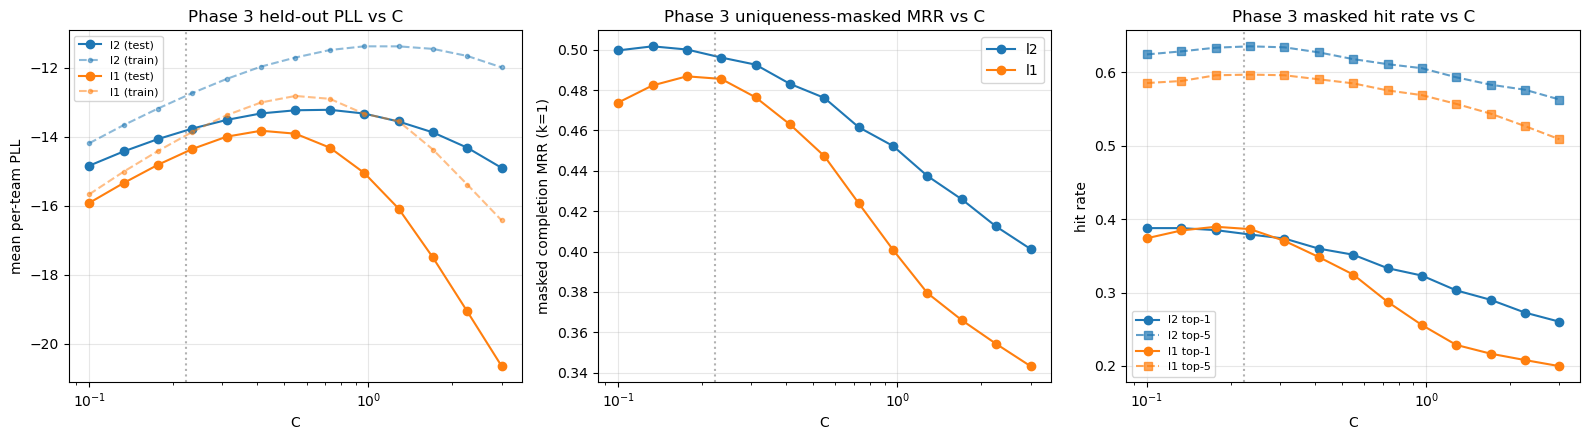

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
colors = {"l2": "C0", "l1": "C1"}

ax = axes[0]
for p in PENALTIES:
    ax.plot(pair_sweep[p]["C"], pair_sweep[p]["test_pll"], marker="o", color=colors[p], label=f"{p} (test)")
    ax.plot(pair_sweep[p]["C"], pair_sweep[p]["train_pll"], marker=".", ls="--", color=colors[p], alpha=0.5, label=f"{p} (train)")
ax.set_xscale("log"); ax.set_xlabel("C"); ax.set_ylabel("mean per-team PLL")
ax.set_title("Phase 3 held-out PLL vs C"); ax.grid(alpha=0.3); ax.legend(fontsize=8)

ax = axes[1]
for p in PENALTIES:
    ax.plot(pair_sweep[p]["C"], pair_sweep[p]["mrr"], marker="o", color=colors[p], label=p)
ax.set_xscale("log"); ax.set_xlabel("C"); ax.set_ylabel("masked completion MRR (k=1)")
ax.set_title("Phase 3 uniqueness-masked MRR vs C"); ax.grid(alpha=0.3); ax.legend()

ax = axes[2]
for p in PENALTIES:
    ax.plot(pair_sweep[p]["C"], pair_sweep[p]["hit1"], marker="o", color=colors[p], label=f"{p} top-1")
    ax.plot(pair_sweep[p]["C"], pair_sweep[p]["hit5"], marker="s", ls="--", color=colors[p], alpha=0.7, label=f"{p} top-5")
ax.set_xscale("log"); ax.set_xlabel("C"); ax.set_ylabel("hit rate")
ax.set_title("Phase 3 masked hit rate vs C"); ax.grid(alpha=0.3); ax.legend(fontsize=8)

for a in axes:
    a.axvline(1/SPECIES_ITEM_LR_LAMBDA, color="gray", ls=":", alpha=0.6)
plt.tight_layout(); plt.show()